# Нагрузка: объяснение inline vs async

Разбор прогонов `bench.sh` из каталогов `run-<explain>-<rate>rps/`. Внутри прогона perm = хранилище (mem/pg) x лимит (без / 1cpu+1gb). Источник: сырой дамп k6 (`<perm>.json`) плюс снимок серверных счётчиков (`<perm>.server.json`).

## Загрузка

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_ROOT = Path('.')
PERM_ORDER = ['mem-unlimited', 'mem-limited', 'pg-unlimited', 'pg-limited']


def load_metadata(run_dir):
    p = run_dir / 'metadata.json'
    return json.loads(p.read_text()) if p.exists() else {}


def dur_seconds(s):
    # '30s' -> 30.0, '500ms' -> 0.5, '1m' -> 60.0
    s = str(s).strip()
    if s.endswith('ms'):
        return float(s[:-2]) / 1000
    if s.endswith('s'):
        return float(s[:-1])
    if s.endswith('m'):
        return float(s[:-1]) * 60
    return float(s)


def metric(m, name, key, default=np.nan):
    # сырой k6 data: metrics.<name>.values.<stat>
    return m.get(name, {}).get('values', {}).get(key, default)


rows = []
for run_dir in sorted(RESULTS_ROOT.glob('run-*')):
    if not run_dir.is_dir():
        continue
    meta = load_metadata(run_dir)
    dur = dur_seconds(meta.get('duration', '30s'))
    for p in sorted(run_dir.glob('*.json')):
        if p.name == 'metadata.json' or p.name.endswith('.server.json'):
            continue
        perm = p.stem
        m = json.loads(p.read_text())['metrics']
        sp = run_dir / (perm + '.server.json')
        server = json.loads(sp.read_text()) if sp.exists() else {}
        explained = server.get('explained', np.nan)
        rows.append({
            'run': run_dir.name,
            'explain': meta.get('explain'),
            'rate': meta.get('rate'),
            'perm': perm,
            'score_p99': metric(m, 'score_latency', 'p(99)'),
            'get_p99': metric(m, 'explain_latency', 'p(99)'),
            'wait_p99': metric(m, 'explain_wait', 'p(99)'),
            'found': metric(m, 'explain_found', 'rate'),
            'http_rate': metric(m, 'http_reqs', 'rate'),
            'explained_per_s': explained / dur if dur else np.nan,
            'dropped': server.get('queue_dropped', np.nan),
        })

df = pd.DataFrame(rows)
df['perm'] = pd.Categorical(df['perm'], categories=PERM_ORDER, ordered=True)
df = df.sort_values(['run', 'perm']).reset_index(drop=True)
df

,run,explain,rate,perm,score_p99,get_p99,wait_p99,found,http_rate,explained_per_s,dropped
0,run-async-1000rps,async,1000,mem-unlimited,1.026386,0.998938,5.936626,1.000000,1864.791220,499.733333,0
1,run-async-1000rps,async,1000,mem-limited,1.208388,1.377512,6.049086,1.000000,1792.374499,496.900000,0
2,run-async-1000rps,async,1000,pg-unlimited,0.619755,0.742626,10.094602,1.000000,2001.787480,498.400000,0
3,run-async-1000rps,async,1000,pg-limited,0.672506,0.990395,10.088376,1.000000,2006.670120,500.866667,0
4,run-async-4000rps,async,4000,mem-unlimited,1.172579,1.133197,6.016240,1.000000,7587.741785,2004.300000,0
5,run-async-4000rps,async,4000,mem-limited,1.759764,1.646963,6.272357,1.000000,6683.858842,2001.400000,0
6,run-async-4000rps,async,4000,pg-unlimited,4.917794,7.368707,98.108799,0.004796,43628.453293,1205.100000,23687
7,run-async-4000rps,async,4000,pg-limited,41.940212,17.805848,111.505481,0.004694,35101.549796,201.800000,42308
8,run-inline-1000rps,inline,1000,mem-unlimited,1.285357,0.685528,0.685528,1.000000,1499.179529,1000.033333,0
9,run-inline-1000rps,inline,1000,mem-limited,1.302813,0.724721,0.724721,1.000000,1499.534042,1000.033333,0


## Графики

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
PALETTE = dict(zip(PERM_ORDER, sns.color_palette('tab10', len(PERM_ORDER))))


def annotate(ax, fmt='%.2f'):
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, padding=3, fontsize=9)


def plot_run(df_all, run_name):
    d = df_all[df_all['run'] == run_name]
    if d.empty:
        print('no data:', run_name)
        return
    order = [p for p in PERM_ORDER if p in set(d['perm'])]

    def bar(a, y, ylabel, fmt):
        sns.barplot(data=d, x='perm', y=y, order=order, hue='perm',
                    hue_order=order, palette=PALETTE, legend=False, ax=a)
        annotate(a, fmt)
        a.set_xlabel('')
        a.set_ylabel(ylabel)
        a.tick_params(axis='x', rotation=15)

    fig, ax = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    fig.suptitle(run_name, fontsize=14)
    bar(ax[0, 0], 'score_p99', '/score p99 (ms)', '%.2f')
    ax[0, 0].set_title('/score p99 (hot path)')
    bar(ax[0, 1], 'found', 'explained fraction', '%.2f')
    ax[0, 1].set_title('declines explained (explain_found)')
    ax[0, 1].set_ylim(0, 1.08)
    bar(ax[1, 0], 'explained_per_s', 'explanations/s', '%.0f')
    ax[1, 0].set_title('explanation throughput')
    a = ax[1, 1]
    sns.scatterplot(data=d, x='score_p99', y='found', hue='perm',
                    hue_order=order, palette=PALETTE, s=160, ax=a)
    a.set_title('/score p99 vs explained fraction')
    a.set_xlabel('/score p99 (ms)')
    a.set_ylabel('explained fraction')
    a.set_ylim(-0.05, 1.08)
    plt.show()

## Прогоны

In [3]:
sorted(df['run'].unique())

['run-async-1000rps',
 'run-async-4000rps',
 'run-inline-1000rps',
 'run-inline-4000rps']

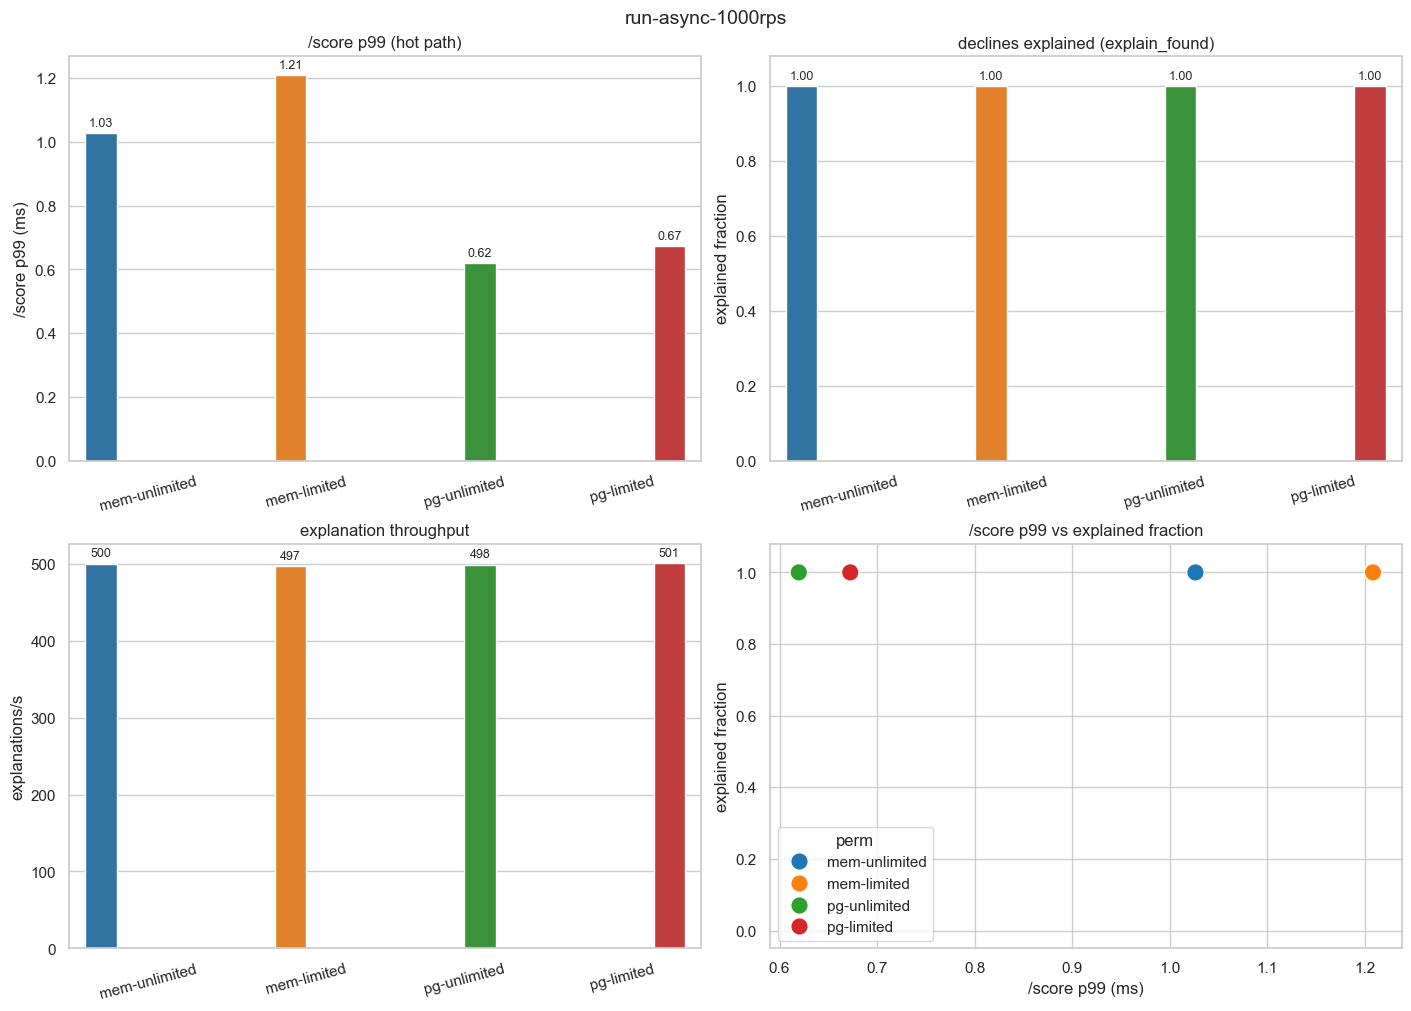

In [4]:
plot_run(df, 'run-async-1000rps')

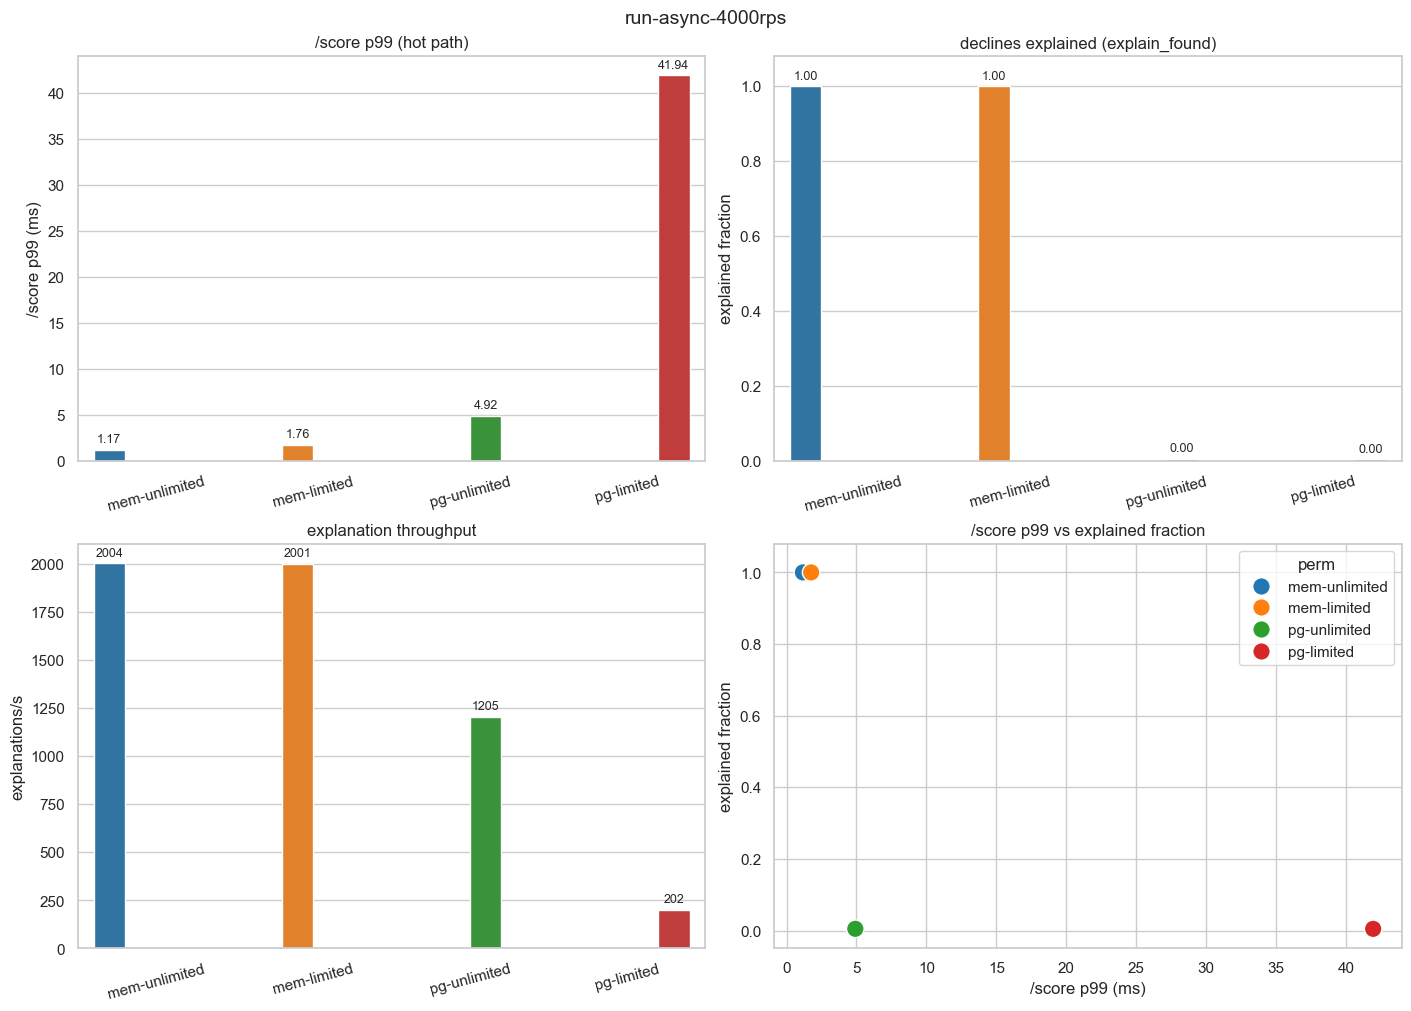

In [5]:
plot_run(df, 'run-async-4000rps')

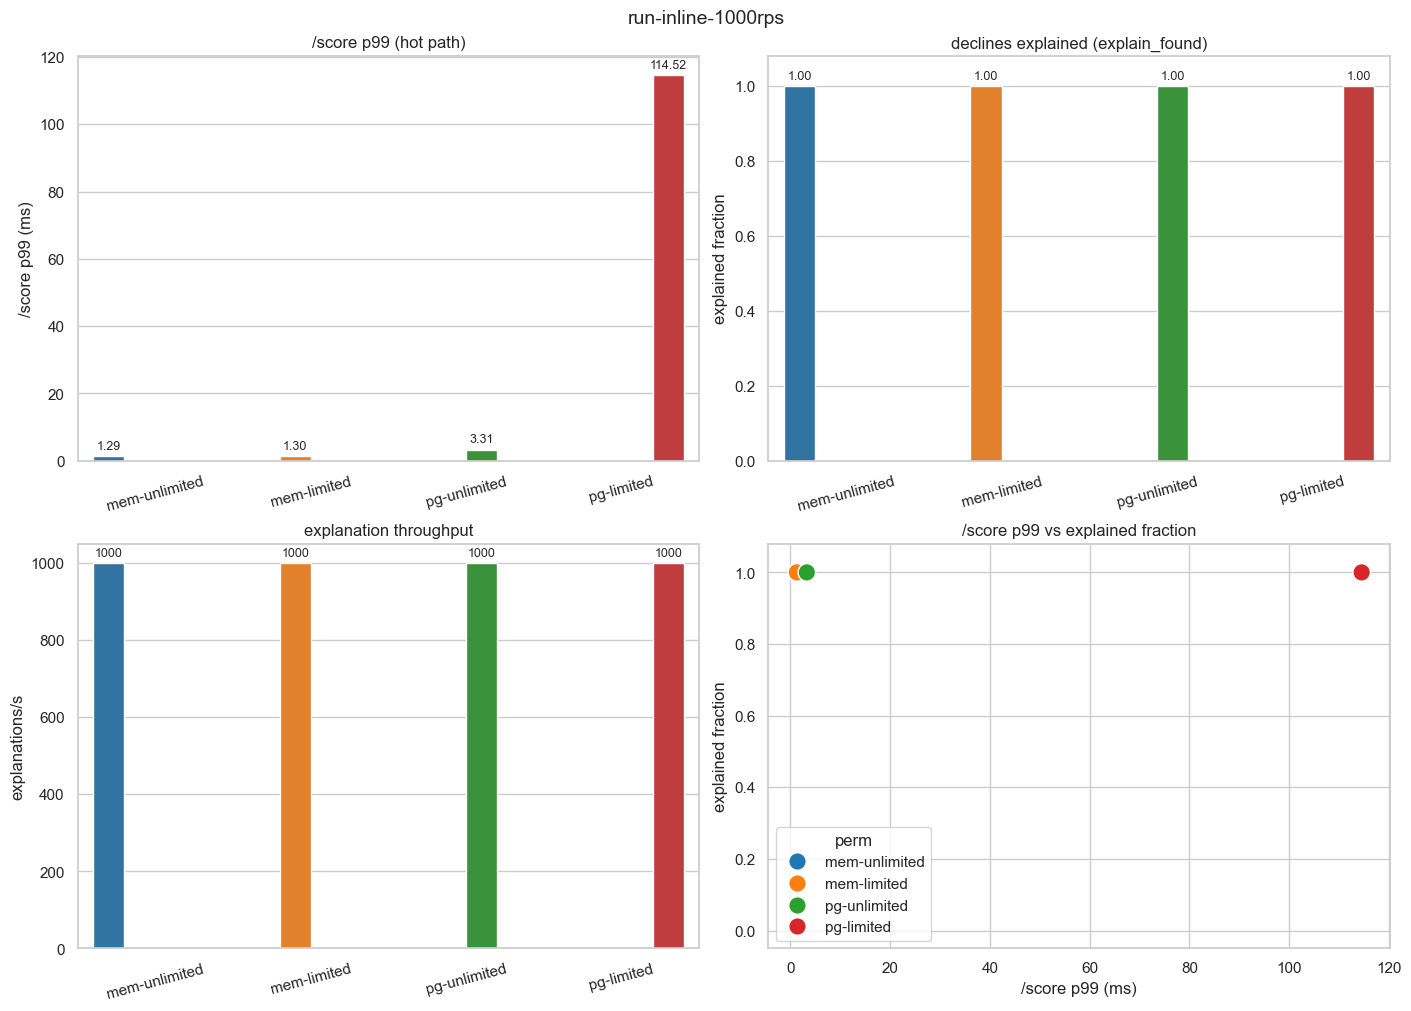

In [6]:
plot_run(df, 'run-inline-1000rps')

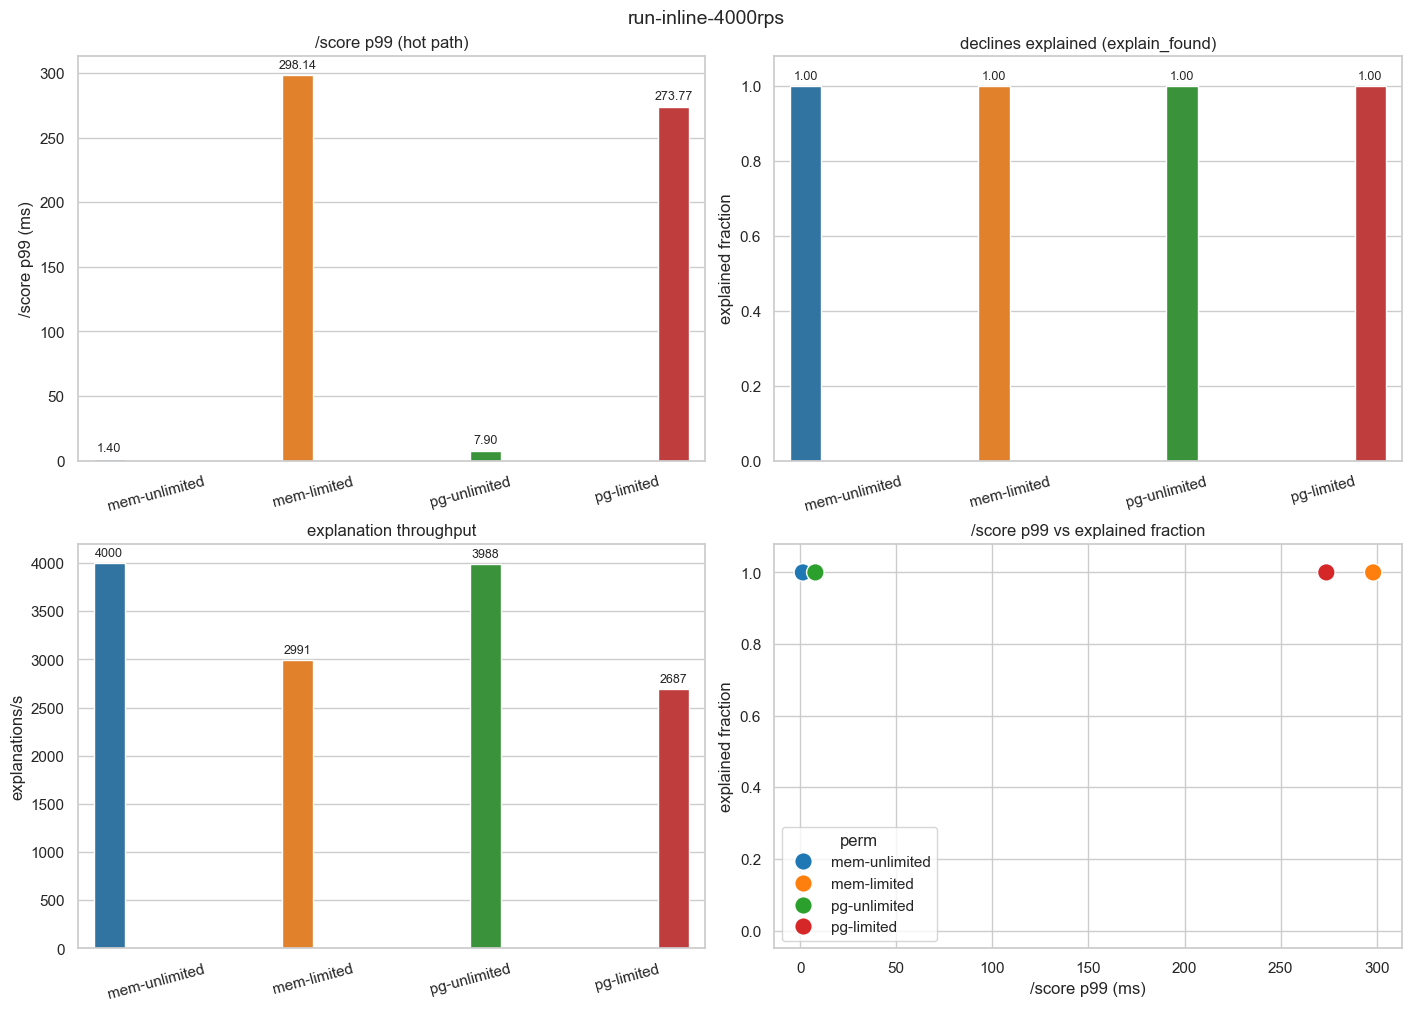

In [7]:
plot_run(df, 'run-inline-4000rps')

## Выводы

Числа - из таблицы и графиков выше (4000 rps = стресс, ~2000 отклонений/с).

**Объяснение на горячем пути (inline) повышает надёжность.** async под пиком переполняет очередь SHAP и теряет объяснения молча: на pg при 4000 rps `found` падает до 0, а `dropped` - 23687 (без лимита) и 42308 (1 CPU). inline убирает очередь как класс: во всех 16 ячейках `found`=1.00, `dropped`=0 - объяснение считается и сохраняется в самом запросе, терять нечем.

**Контринтуитивно растёт и пропускная способность объяснений.** async упирается в `workers=2`: pg без лимита под стрессом отдаёт ~1205 объяснений/с и теряет остальное. inline параллелит SHAP по всем горячим хэндлам и на той же pg без лимита доставляет ~3988 объяснений/с при нуле потерь - втрое больше и без потерь.

**Цена - латентность `/score` и вдвое больше работы CPU** (inline считает SHAP для КАЖДОГО решения, а не только отклонений). При избытке ядер цена мала: mem без лимита `/score` p99 ~1.4 мс, pg без лимита ~7.9 мс (синхронный commit на горячем пути). Под 1 CPU горячий путь насыщается: p99 274-298 мс, доставленная пропускная способность проседает с 4000 до ~2700-3000/с (сброс 25-33%); на pg под 1 CPU латентность видна уже при 1000 rps (p99 ~115 мс).

**Режим отказа становится явным.** async под перегрузкой возвращает быстрые решения без объяснений (тихая потеря). inline замедляет и сбрасывает запросы (видимый backpressure) - но что обслужено, то объяснено. Для объяснимости отказов это и есть искомая надёжность.

Выбор: async - когда нужен максимально быстрый и ёмкий `/score`, а объяснения допустимо терять под пиком; inline - когда у каждого решения обязано быть объяснение, и за это можно платить латентностью и CPU.